# Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from utils.feature_importance_utils import (
    block_shuffle_1d,
    permutation_importance_global_sequence,
)

print("tf:", tf.__version__)
print("keras:", keras.__version__)

tf: 2.20.0
keras: 3.13.2


In [ ]:
# def block_shuffle_1d(x, block_size, rng):
#     """
#     x: shape (T,)
#     Returns x with contiguous blocks permuted.
#     """
#     T = len(x)
#     n_blocks = int(np.ceil(T / block_size))
#     pad_len = n_blocks * block_size - T
#     # pad to full blocks
#     if pad_len > 0:
#         x_pad = np.pad(x, (0, pad_len), mode="edge")
#     else:
#         x_pad = x
#     blocks = x_pad.reshape(n_blocks, block_size)  # (B, block_size)
#     perm = rng.permutation(n_blocks)
#     x_shuf = blocks[perm].reshape(-1)[:T]
#     return x_shuf

# def permutation_importance_global_sequence(
#     model,
#     X_val,                  # shape: (N, T, F)
#     y_val,                  # shape: (N, T) or model-compatible target
#     feature_names=None,
#     n_repeats=5,
#     batch_size=128,
#     sample_weight=None,     # optional mask/weights, shape usually (N, T)
#     shuffle_mode="sequence",# "sequence" or "per_timestep"
#     random_state=42,
# ):
#     """
#     Global permutation importance for sequence models (GRU/LSTM), no retraining.
#     Importance = mean(permuted_loss - baseline_loss) across repeats.
#     """

#     rng = np.random.default_rng(random_state)

#     # 1) Baseline validation loss (trained model, no retraining)
#     baseline = model.evaluate(
#         X_val, y_val,
#         sample_weight=sample_weight,
#         batch_size=batch_size,
#         verbose=0,
#         return_dict=True
#     )
#     baseline_loss = baseline["loss"]

#     n_features = X_val.shape[2]
#     if feature_names is None:
#         feature_names = [f"feature_{i}" for i in range(n_features)]

#     results = []

#     # 2) Permute one feature at a time, recompute loss
#     for j in range(n_features):
#         deltas = []
#         print(f"Permutation feature {feature_names[j]}")
#         for _ in range(n_repeats):
#             Xp = X_val.copy()

#             if shuffle_mode == "sequence":
#                 # Shuffle entire trajectory of feature j across samples:
#                 # preserves within-trial temporal structure for that feature.
#                 perm_idx = rng.permutation(X_val.shape[0])
#                 Xp[:, :, j] = X_val[perm_idx, :, j]

#             elif shuffle_mode == "per_timestep":
#                 # Shuffle feature j across samples independently at each time t.
#                 for t in range(X_val.shape[1]):
#                     perm_idx = rng.permutation(X_val.shape[0])
#                     Xp[:, t, j] = X_val[perm_idx, t, j]
#             elif shuffle_mode == "within_sample":
#                 # independently shuffle timesteps within each sample for feature j
#                 for n in range(X_val.shape[0]):
#                     Xp[n, :, j] = rng.permutation(X_val[n, :, j])
#             elif shuffle_mode == "within_sample_block":
#                 # Shuffle blocks of timesteps within each sample for feature j
#                 for n in range(X_val.shape[0]):
#                     Xp[n, :, j] = block_shuffle_1d(
#                         X_val[n, :, j],
#                         block_size=32,   # tune this
#                         rng=rng
#                     )                    
#             else:
#                 raise ValueError("shuffle_mode must be 'sequence' or 'per_timestep'")

#             perm_eval = model.evaluate(
#                 Xp, y_val,
#                 sample_weight=sample_weight,
#                 batch_size=batch_size,
#                 verbose=0,
#                 return_dict=True
#             )
#             perm_loss = perm_eval["loss"]
#             print(f"Permutation loss: {perm_loss}")
#             deltas.append(perm_loss - baseline_loss)  # degradation

#         results.append({
#             "feature": feature_names[j],
#             "importance_mean": float(np.mean(deltas)),
#             "importance_std": float(np.std(deltas)),
#             "baseline_loss": float(baseline_loss),
#             "permuted_loss_mean": float(baseline_loss + np.mean(deltas)),
#         })

#     ranking = pd.DataFrame(results).sort_values("importance_mean", ascending=False).reset_index(drop=True)
#     return ranking

# Load features and model

In [2]:
model_name = "rlf"
N_AGENTS = 500
num_blocks = 12
max_num_trials = 78
suffix = '3ParamRL_no_switch_st22'
filename = f"./data/{model_name}_6s3a/{N_AGENTS}a_{num_blocks}b_{max_num_trials}t_{suffix}.csv"
print(filename)
test_data = pd.read_csv(filename)

./data/rlf_6s3a/500a_12b_78t_3ParamRL_no_switch_st22.csv


In [4]:
from utils.feature_utils import (
    get_iter_acc_without_switches,
    get_iter_acc_with_switches,
    extract_features_blockless,
)

%matplotlib inline
import warnings; warnings.simplefilter('ignore')  # hide warnings
feature_list = ['actions', 'rewards',  'stimuli','isswitch','delay_since_last_stimuli']

has_switches = (test_data.isswitch.nunique() == 2)
test_iter = get_iter_acc_with_switches(test_data) if has_switches else get_iter_acc_without_switches(test_data)
test_iter['isswitch'] = test_iter['trials'].apply(lambda x: 1 if x == 0 else 0)
test_iter['prev_action'] = test_data.groupby(['agentid', 'block_no'])['actions'].shift(1).fillna(-1).astype(int).to_list()
test_iter['delay_since_last_stimuli'] = test_data['delay_since_last_stimuli'].to_list()

test_features = extract_features_blockless(test_iter, feature_list, [])
#test_features = _extract_features_blockless(test_iter, feature_list, False)#get_block_onehot_features(short_test_data, feature_list) #

num_test_agents = test_data['agentid'].nunique()
n_trial = test_data['trials'].nunique()
n_block = test_data['block_no'].nunique()
qv = np.array(test_data['rewards'] - test_data['rpe_history'])
test_labels = qv.astype(np.float32).reshape((num_test_agents, n_block*n_trial))

print(test_features.shape, test_labels.shape)

(500, 936, 5) (500, 936)


In [5]:
model_name = "lasenet_RLF-6S3A_a-r-s-i-d_A3000_936t_B128_U256_D0.097_D0.013_D0.011_0.000696_model.keras"
gru_model = tf.keras.models.load_model(f"./models/{model_name}", compile=True)

# Evaluate

## Block size shuffle

In [ ]:
block_sizes = [16, 32, 64]
all_rankings = {}
for bs in block_sizes:
    ranking_bs = permutation_importance_global_sequence(
        model=gru_model,
        X_val=test_features,
        y_val=test_labels,
        feature_names=feature_list,
        n_repeats=3,
        batch_size=128,
        sample_weight=None,
        shuffle_mode="within_sample_block",
        random_state=123,
        block_size=bs,   # add this arg to your function
    )
    ranking_bs["block_size"] = bs
    all_rankings[bs] = ranking_bs

combined = pd.concat(all_rankings.values(), ignore_index=True)
combined.head()

Permutation feature actions
Permutation loss: 0.004092930816113949
Permutation loss: 0.004148680716753006
Permutation loss: 0.00411721458658576
Permutation loss: 0.00412890175357461


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=combined,
    x="feature",
    y="importance_mean",
    hue="block_size"
)
plt.xticks(rotation=45, ha="right")
plt.title("Permutation Importance Across Block Sizes")
plt.tight_layout()
plt.show()

## All time sequences shuffle within sample/participant/agent

In [7]:
# X_test: (500, 936, 5), y_test: (500, 936)
feature_names = feature_list

ranking = permutation_importance_global_sequence(
    model=gru_model,     # already trained once
    X_val=test_features,
    y_val=test_labels,
    feature_names=feature_names,
    n_repeats=3,
    batch_size=64,
    sample_weight=None,  # put mask here if you use padded timesteps
    shuffle_mode="within_sample",
    random_state=123
)

print(ranking)

Permutation feature actions
Permutation loss: 0.004168259911239147
Permutation loss: 0.0041869087144732475
Permutation loss: 0.004150552209466696
Permutation feature rewards
Permutation loss: 0.03058036044239998
Permutation loss: 0.030542153865098953
Permutation loss: 0.03037191741168499
Permutation feature stimuli
Permutation loss: 0.004546891897916794
Permutation loss: 0.004564210306853056
Permutation loss: 0.004544719122350216
Permutation feature isswitch
Permutation loss: 0.004254962783306837
Permutation loss: 0.004255539271980524
Permutation loss: 0.00424170820042491
Permutation feature delay_since_last_stimuli
Permutation loss: 0.021030962467193604
Permutation loss: 0.02089712768793106
Permutation loss: 0.020660346373915672
                    feature  importance_mean  importance_std  baseline_loss  \
0                   rewards         0.026385        0.000091       0.004113   
1  delay_since_last_stimuli         0.016750        0.000153       0.004113   
2                   sti

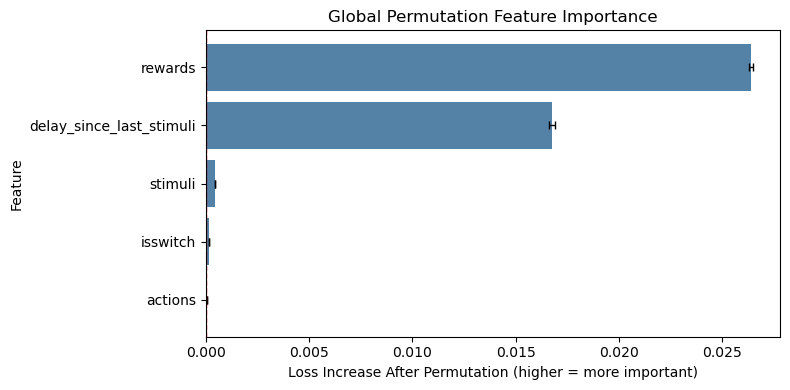

In [8]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=ranking,
    x="importance_mean",
    y="feature",
    color="steelblue"
)
# add error bars if present
if "importance_std" in ranking.columns:
    ax.errorbar(
        x=ranking["importance_mean"],
        y=range(len(ranking)),
        xerr=ranking["importance_std"],
        fmt="none",
        ecolor="black",
        capsize=3,
        lw=1
    )
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Global Permutation Feature Importance")
ax.set_xlabel("Loss Increase After Permutation (higher = more important)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()